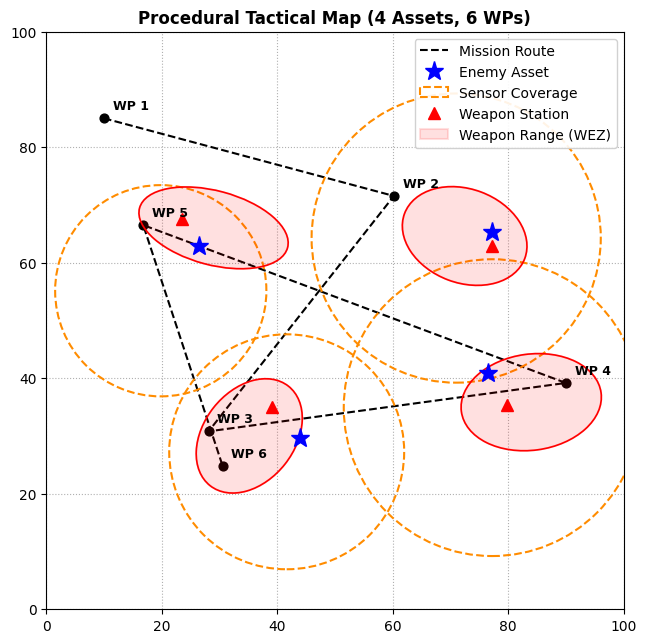

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.linalg as la

np.random.seed()

num_assets = np.random.randint(2, 5)

assets = []
sensors = []
weapons = []

quadrants = [
    (55, 80, 50, 80),
    (15, 45, 15, 45),
    (60, 85, 15, 45),
    (15, 45, 50, 75)   #
]
# np.random.shuffle(quadrants) # Mix up positioning order

for idx in range(num_assets):
    xmin, xmax, ymin, ymax = quadrants[idx]
    pos_x = np.random.uniform(xmin, xmax)
    pos_y = np.random.uniform(ymin, ymax)
    asset_pos = (pos_x, pos_y)

    assets.append({"pos": asset_pos, "label": f"Asset {idx+1}"})

    sensors.append({
        "pos": (asset_pos[0] + np.random.uniform(-8, 5), asset_pos[1] + np.random.uniform(-8, 5)),
        "radius": np.random.uniform(18, 26)
    })

    weapons.append({
        "station": (asset_pos[0] + np.random.uniform(-6, 6), asset_pos[1] + np.random.uniform(-6, 6)),
        "a": np.random.uniform(10, 14),
        "b": np.random.uniform(6, 8.5),
        "offset": np.random.uniform(4, 6.5)
    })

num_waypoints = num_assets + np.random.randint(1, 4) # WAHOO LETYS GO GAMBLIG

wp_list = []
# Fixed safe start point
wp_list.append([10, np.random.uniform(75, 90)])

for w_idx in range(1, num_waypoints - 1):
    # make route close tosenseors
    target_sensor = sensors[min(w_idx - 1, len(sensors) - 1)]
    sx, sy = target_sensor["pos"]

    wp_x = np.clip(sx + np.random.uniform(-15, 15), 10, 90)
    wp_y = np.clip(sy + np.random.uniform(-15, 15), 10, 90)
    wp_list.append([wp_x, wp_y])

# finish wp
wp_list.append([np.random.uniform(10, 35), np.random.uniform(10, 30)])
waypoints = np.array(wp_list)

fig, ax1 = plt.subplots(figsize=(8, 7.5))

ax1.plot(waypoints[:, 0], waypoints[:, 1], 'k--', lw=1.5, label='Mission Route')
ax1.scatter(waypoints[:, 0], waypoints[:, 1], color='black', s=40, zorder=5)
for i, wp in enumerate(waypoints):
    ax1.text(wp[0] + 1.5, wp[1] + 1.5, f"WP {i+1}", fontsize=9, weight='bold', zorder=6)

for idx, asset in enumerate(assets):
    ax1.plot(asset["pos"][0], asset["pos"][1], 'b*', ms=14, zorder=7, label='Enemy Asset' if idx == 0 else "")

for idx, sensor in enumerate(sensors):
    circle = patches.Circle(sensor["pos"], sensor["radius"], edgecolor='darkorange', facecolor='none', linestyle='--', lw=1.5, zorder=4, label='Sensor Coverage' if idx == 0 else "")
    ax1.add_patch(circle)

for idx, weapon in enumerate(weapons):
    xw, yw = weapon["station"]

    distances = [np.linalg.norm(np.mean([waypoints[j], waypoints[j+1]], axis=0) - [xw, yw]) for j in range(len(waypoints)-1)]
    current_leg = np.argmin(distances)
    p1, p2 = waypoints[current_leg], waypoints[current_leg + 1]

    angle_rad = np.arctan2(p2[1] - p1[1], p2[0] - p1[0])

    # Shift ellipse center forward along velocity trajectory
    xc = xw + weapon["offset"] * np.cos(angle_rad)
    yc = yw + weapon["offset"] * np.sin(angle_rad)

    # Plot weapons infrastructure
    ax1.plot(xw, yw, 'r^', ms=9, zorder=5, label='Weapon Station' if idx == 0 else "")

    ellipse = patches.Ellipse(xy=(xc, yc), width=weapon["a"]*2, height=weapon["b"]*2, angle=np.degrees(angle_rad), edgecolor='red', facecolor='red', alpha=0.12, lw=1.5, zorder=5, label='Weapon Range (WEZ)' if idx == 0 else "")
    ax1.add_patch(ellipse)

    ellipse_outline = patches.Ellipse(xy=(xc, yc), width=weapon["a"]*2, height=weapon["b"]*2, angle=np.degrees(angle_rad), edgecolor='red', facecolor='none', lw=1.2, zorder=5)
    ax1.add_patch(ellipse_outline)

ax1.set_title(f"Procedural Tactical Map ({num_assets} Assets, {num_waypoints} WPs)", fontsize=12, weight='bold')
ax1.set_xlim(0, 100); ax1.set_ylim(0, 100); ax1.grid(True, ls=':'); ax1.set_aspect('equal')
ax1.legend(loc='upper right', framealpha=0.9)
plt.show()

Tracking model (Chap. III) — continuous-time Markov chain over the 4 states Undetected -> Detected -> Tracked -> Identified, propagated with the matrix exponential p(t) = p(t-dt) e^(Λ dt). When the aircraft is covered by multiple sensors simultaneously, the individual sensor intensities are summed (1/τ_tot = Σ 1/τ_i), per the overlap formula at the end of Chap. III.

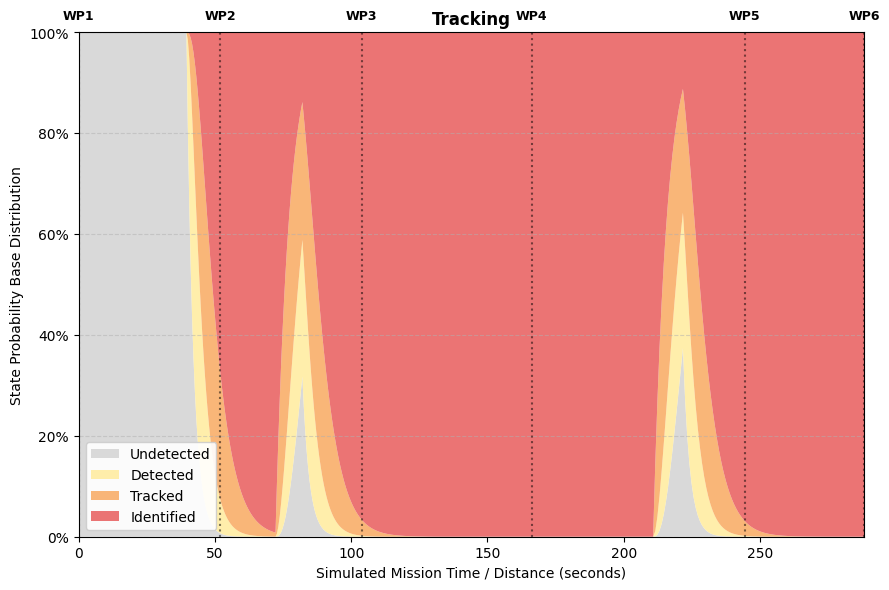

In [2]:
num_steps_per_leg = 100
path_points = []
for i in range(len(waypoints) - 1):
    leg = np.linspace(waypoints[i], waypoints[i+1], num_steps_per_leg, endpoint=False)
    path_points.extend(leg)
path_points.append(waypoints[-1])
path_points = np.array(path_points)

# Calculate elapsed step intervals assuming constant speed v = 1 unit/sec
segment_lengths = np.sqrt(np.sum(np.diff(path_points, axis=0)**2, axis=1))
time_steps = np.zeros(len(path_points))
time_steps[1:] = np.cumsum(segment_lengths)

# 2. Setup the Tracking States Matrix [Undetected, Detected, Tracked, Identified]
prob_history = np.zeros((len(path_points), 4))
prob_history[0] = [1.0, 0.0, 0.0, 0.0]  # Commences 100% undetected

# Expected time before transition (Table I, Chap. III)
#   Within sensor range  (escalation, states move right):  tau_UD, tau_DT, tau_TI
#   Outside sensor range (regression, states move left):    tau_DU, tau_TD, tau_IT
tau_UD, tau_DT, tau_TI = 2.5, 3.3, 5.0
tau_DU, tau_TD, tau_IT = 5.0, 5.0, 5.0

# 3. Propagate state distributions dynamically along the trajectory coordinates
for t in range(1, len(path_points)):
    dt = time_steps[t] - time_steps[t-1]
    pos = path_points[t]

    # Which sensors currently cover this position (Cartesian circle test)
    covering_sensors = [s for s in sensors if np.linalg.norm(pos - s["pos"]) <= s["radius"]]
    n_cover = len(covering_sensors)

    # Construct infinitesimal generator matrix Λ
    Lambda = np.zeros((4, 4))
    if n_cover > 0:
        # Overlap equation: independent sensors detect/track the
        # aircraft independently, so the intensities (1/tau) for an area
        # covered by multiple sensors simply add up:
        #     1/tau_tot_ij = sum_k 1/tau_ij^(k)
        # (for sensors sharing the same tau this reduces to n_cover/tau).
        rate_UD = sum(1.0 / tau_UD for _ in covering_sensors)
        rate_DT = sum(1.0 / tau_DT for _ in covering_sensors)
        rate_TI = sum(1.0 / tau_TI for _ in covering_sensors)
        Lambda[0, 1] = rate_UD   # Undetected -> Detected
        Lambda[1, 2] = rate_DT   # Detected   -> Tracked
        Lambda[2, 3] = rate_TI   # Tracked    -> Identified
    else:
        # Regression/forgetting transitions take over outside radar coverage
        Lambda[1, 0] = 1.0 / tau_DU   # Detected   -> Undetected
        Lambda[2, 1] = 1.0 / tau_TD   # Tracked    -> Detected
        Lambda[3, 2] = 1.0 / tau_IT   # Identified -> Tracked

    # Apply row balance properties: Diagonals = -Sum(off-diagonals)
    for r in range(4):
        Lambda[r, r] = -np.sum(Lambda[r, :])

    # p(t) = p(t-dt) * e^(Λ * dt)
    prob_history[t] = prob_history[t-1] @ la.expm(Lambda * dt)

fig, ax2 = plt.subplots(figsize=(9, 6))

ax2.stackplot(time_steps, prob_history[:, 0], prob_history[:, 1], prob_history[:, 2], prob_history[:, 3],
              labels=['Undetected', 'Detected', 'Tracked', 'Identified'],
              colors=['#d3d3d3', '#ffeb9c', '#f8a961', '#e85c5c'], alpha=0.85)

# Synchronize labels marking when waypoints occur chronologically on the timeline
wp_indices = [0] + [(j+1) * num_steps_per_leg for j in range(len(waypoints)-1)]
for idx, i in enumerate(wp_indices):
    t_val = time_steps[min(i, len(time_steps)-1)]
    ax2.axvline(x=t_val, color='black', linestyle=':', alpha=0.5)
    ax2.text(t_val, 1.02, f"WP{idx+1}", ha='center', va='bottom', fontsize=9, weight='bold')

ax2.set_title("Tracking", fontsize=12, weight='bold')
ax2.set_xlabel("Simulated Mission Time / Distance (seconds)")
ax2.set_ylabel("State Probability Base Distribution")
ax2.set_ylim(0, 1.0)
ax2.set_xlim(0, time_steps[-1])
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax2.legend(loc='lower left', framealpha=0.9)
ax2.grid(axis='y', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()


Threat Value, TV (Sec. IV-B) — discrete distance bands to the nearest asset, exactly as defined in the paper: TV ∈ {1, 0.9, 0.7, 0.5, 0} for {very close, close, medium, far, very far}, rather than a continuous gradient.

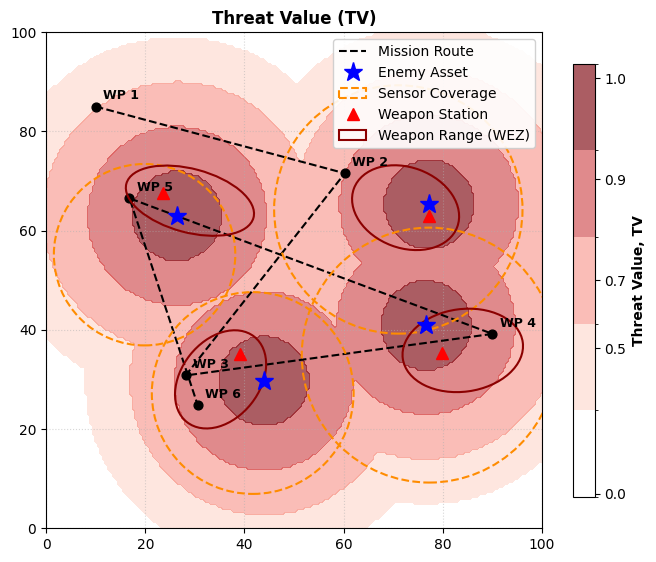

In [3]:
from matplotlib.colors import ListedColormap, BoundaryNorm

grid_x, grid_y = np.meshgrid(np.linspace(0, 100, 200), np.linspace(0, 100, 200))
influence_radius = 45.0

def threat_value_band(distance, R=influence_radius):
    conditions = [distance <= 0.2 * R,
                  distance <= 0.4 * R,
                  distance <= 0.6 * R,
                  distance <= 0.8 * R]
    choices = [1.0, 0.9, 0.7, 0.5]
    return np.select(conditions, choices, default=0.0)

threat_grid = np.zeros_like(grid_x)
for asset in assets:
    ax_pos, ay_pos = asset["pos"]
    distance = np.sqrt((grid_x - ax_pos)**2 + (grid_y - ay_pos)**2)
    asset_threat = threat_value_band(distance)
    threat_grid = np.maximum(threat_grid, asset_threat)

fig, ax3 = plt.subplots(figsize=(8, 7.5))

# Discrete colormap with hard edges at each TV band (no interpolation/gradient)
tv_levels  = [0.0, 0.5, 0.7, 0.9, 1.0]
tv_bounds  = [-0.01, 0.25, 0.6, 0.8, 0.95, 1.01]
tv_colors  = plt.cm.Reds(np.linspace(0.25, 0.95, len(tv_levels)))
tv_colors[:, 3] = [0.0, 0.2, 0.35, 0.5, 0.65]   # opacity per band (0 -> transparent)
custom_cmap = ListedColormap(tv_colors)
norm = BoundaryNorm(tv_bounds, custom_cmap.N)

contour_plot = ax3.contourf(grid_x, grid_y, threat_grid, levels=tv_bounds, cmap=custom_cmap, norm=norm)

ax3.plot(waypoints[:, 0], waypoints[:, 1], 'k--', lw=1.5, label='Mission Route')
ax3.scatter(waypoints[:, 0], waypoints[:, 1], color='black', s=40, zorder=5)
for i, wp in enumerate(waypoints):
    ax3.text(wp[0] + 1.5, wp[1] + 1.5, f"WP {i+1}", fontsize=9, weight='bold', zorder=6)

for asset in assets:
    ax3.plot(asset["pos"][0], asset["pos"][1], 'b*', ms=14, zorder=7, label='Enemy Asset' if asset == assets[0] else "")

for i, sensor in enumerate(sensors):
    circle = patches.Circle(sensor["pos"], sensor["radius"], edgecolor='darkorange', facecolor='none', linestyle='--', lw=1.5, zorder=4, label='Sensor Coverage' if i == 0 else "")
    ax3.add_patch(circle)

for i, weapon in enumerate(weapons):
    xw, yw = weapon["station"]
    distances = [np.linalg.norm(np.mean([waypoints[j], waypoints[j+1]], axis=0) - [xw, yw]) for j in range(len(waypoints)-1)]
    current_leg = np.argmin(distances)
    p1, p2 = waypoints[current_leg], waypoints[current_leg + 1]
    angle_rad = np.arctan2(p2[1] - p1[1], p2[0] - p1[0])

    xc = xw + weapon["offset"] * np.cos(angle_rad)
    yc = yw + weapon["offset"] * np.sin(angle_rad)

    ax3.plot(xw, yw, 'r^', ms=9, zorder=5, label='Weapon Station' if i == 0 else "")
    ellipse_outline = patches.Ellipse(xy=(xc, yc), width=weapon["a"]*2, height=weapon["b"]*2, angle=np.degrees(angle_rad), edgecolor='darkred', facecolor='none', lw=1.5, zorder=5, label='Weapon Range (WEZ)' if i == 0 else "")
    ax3.add_patch(ellipse_outline)

# Graph Layout Configuration
ax3.set_title("Threat Value (TV)", fontsize=12, weight='bold')
ax3.set_xlim(0, 100); ax3.set_ylim(0, 100); ax3.grid(True, ls=':', alpha=0.5); ax3.set_aspect('equal')

# Colorbar with discrete band ticks matching TV = {0, 0.5, 0.7, 0.9, 1.0}
cbar = fig.colorbar(contour_plot, ax=ax3, shrink=0.75, pad=0.05, ticks=tv_levels)
cbar.set_label('Threat Value, TV', weight='bold')

ax3.legend(loc='upper right', framealpha=0.9)
plt.show()


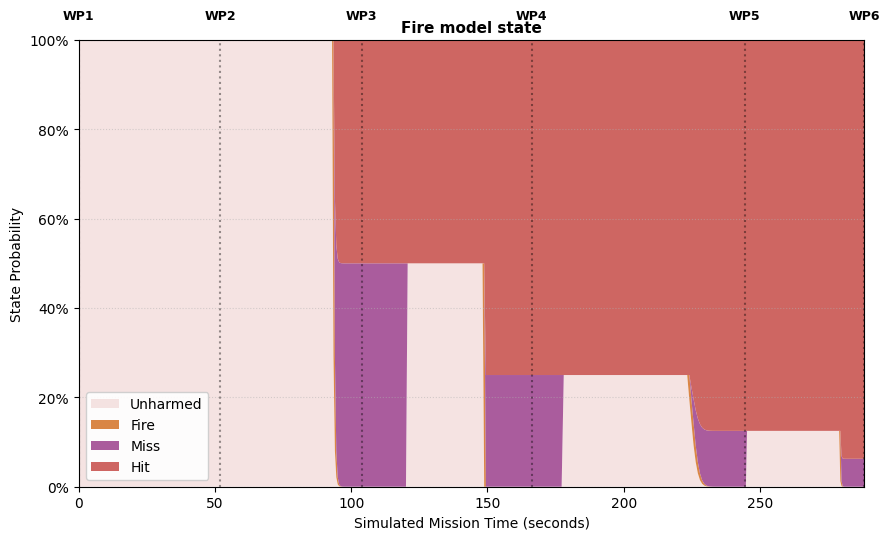

In [4]:
# Fire model (Chap. IV) - discrete-time Markov chain over 4 states:
#   0: Unharmed, 1: Fire (temporary), 2: Miss, 3: Hit
#
# Transition matrix, Sec. IV (eq. for P(tk)):
#
#   P(tk) = [[ 1-p_fire(tk),  p_fire(tk),      0,            0          ],
#            [ 0,             0,               1-p_kill(tk), p_kill(tk)],
#            [ 0,             0,               1,            0         ],
#            [ 0,             0,               0,            1         ]]
#
#   p_FM(tk)^T = p_FM(tk-1)^T P(tk)
#
# p_fire = p_Identified * TV   if the aircraft is inside a weapon range, else 0
# (Sec. IV, just below the transition matrix). p_kill is constant within the
# weapon range (Sec. IV-C). When the aircraft LEAVES a weapon range, all
# probability mass in states Fire and Miss is transferred to Unharmed
# (damage-assessment rule, Sec. IV) - each weapon system can only fire once
# per pass through its range.

p_identified = prob_history[:, 3]

influence_radius = 45.0
path_threat_values = np.zeros(len(path_points))
inside_wez = np.zeros(len(path_points), dtype=bool)

for t, pos in enumerate(path_points):
    # TV(t): discrete-band threat value, max across all protected assets
    tv = 0.0
    for asset in assets:
        dist = np.linalg.norm(pos - asset["pos"])
        tv = max(tv, threat_value_band(dist, influence_radius))
    path_threat_values[t] = tv

    in_zone = False
    for weapon in weapons:
        xw, yw = weapon["station"]
        distances = [np.linalg.norm(np.mean([waypoints[j], waypoints[j+1]], axis=0) - [xw, yw]) for j in range(len(waypoints)-1)]
        current_leg = np.argmin(distances)
        p1, p2 = waypoints[current_leg], waypoints[current_leg + 1]
        angle_rad = np.arctan2(p2[1] - p1[1], p2[0] - p1[0])

        xc = xw + weapon["offset"] * np.cos(angle_rad)
        yc = yw + weapon["offset"] * np.sin(angle_rad)

        dx, dy = pos[0] - xc, pos[1] - yc
        rot_x = dx * np.cos(angle_rad) + dy * np.sin(angle_rad)
        rot_y = -dx * np.sin(angle_rad) + dy * np.cos(angle_rad)

        if (rot_x**2 / weapon["a"]**2) + (rot_y**2 / weapon["b"]**2) <= 1.0:
            in_zone = True
            break
    inside_wez[t] = in_zone

p_fire = np.where(inside_wez, p_identified * path_threat_values, 0.0)
p_kill = 0.5

# Discrete-time fire Markov chain, states = [Unharmed, Fire, Miss, Hit]
fire_probs = np.zeros((len(path_points), 4))
fire_probs[0] = [1.0, 0.0, 0.0, 0.0]

for t in range(1, len(path_points)):
    pf = p_fire[t]
    P = np.array([
        [1.0 - pf, pf,        0.0,            0.0          ],
        [0.0,      0.0,       1.0 - p_kill,   p_kill       ],
        [0.0,      0.0,       1.0,            0.0          ],
        [0.0,      0.0,       0.0,            1.0          ],
    ])
    fire_probs[t] = fire_probs[t-1] @ P

    # Unharmed conversion
    if inside_wez[t-1] and not inside_wez[t]:
        fire_probs[t, 0] += fire_probs[t, 1] + fire_probs[t, 2]
        fire_probs[t, 1] = 0.0
        fire_probs[t, 2] = 0.0

fig, ax4 = plt.subplots(figsize=(9, 5.5))
ax4.stackplot(time_steps,
              fire_probs[:, 0], fire_probs[:, 1], fire_probs[:, 2], fire_probs[:, 3],
              labels=['Unharmed', 'Fire', 'Miss', 'Hit'],
              colors=['#f4e0df', '#d67931', '#a14a92', '#c95551'], alpha=0.9)

# Synchronize Waypoint vertical lines
for idx, i in enumerate(wp_indices):
    t_val = time_steps[min(i, len(time_steps)-1)]
    ax4.axvline(x=t_val, color='black', linestyle=':', alpha=0.4)
    ax4.text(t_val, 1.04, f"WP{idx+1}", ha='center', va='bottom', fontsize=9, weight='bold')

ax4.set_title("Fire model state", fontsize=11, weight='bold')
ax4.set_xlabel("Simulated Mission Time (seconds)")
ax4.set_ylabel("State Probability")
ax4.set_ylim(0, 1.0)
ax4.set_xlim(0, time_steps[-1])
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax4.grid(axis='y', ls=':', alpha=0.5)
ax4.legend(loc='lower left', framealpha=0.9)
plt.tight_layout()
plt.show()


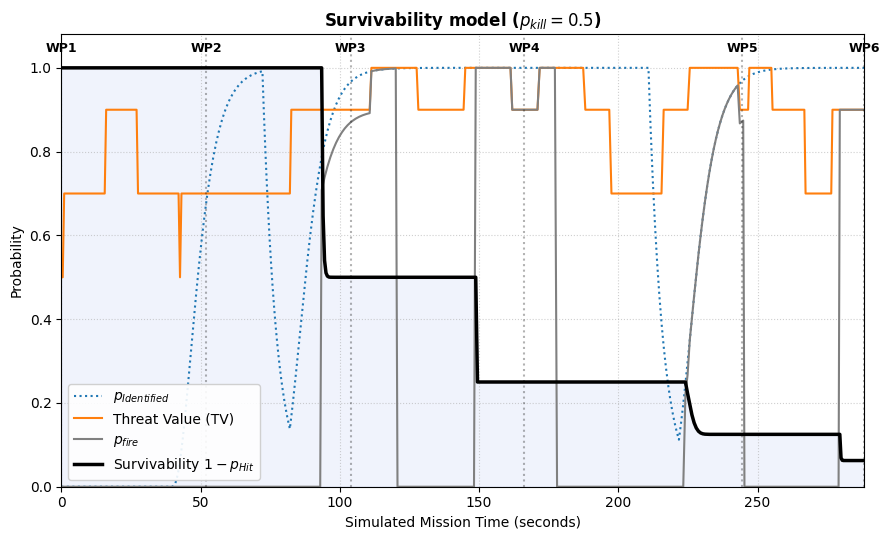

Final survivability at end of route: 6.3%
Final probability of Hit:            93.7%


In [5]:
survival_prob = 1.0 - fire_probs[:, 3]  # 1 - p_Hit

fig, ax5 = plt.subplots(figsize=(9, 5.5))
ax5.plot(time_steps, p_identified, ':', color='tab:blue', lw=1.5, label='$p_{Identified}$')
ax5.plot(time_steps, path_threat_values, '-', color='tab:orange', lw=1.5, label='Threat Value (TV)')
ax5.plot(time_steps, p_fire, '-', color='gray', lw=1.5, label='$p_{fire}$')
ax5.plot(time_steps, survival_prob, 'k-', lw=2.5, label='Survivability $1-p_{Hit}$')
ax5.fill_between(time_steps, survival_prob, color='royalblue', alpha=0.08)

for idx, i in enumerate(wp_indices):
    t_val = time_steps[min(i, len(time_steps)-1)]
    ax5.axvline(x=t_val, color='black', linestyle=':', alpha=0.3)
    ax5.text(t_val, 1.03, f"WP{idx+1}", ha='center', va='bottom', fontsize=9, weight='bold')

ax5.set_title(f"Survivability model ($p_{{kill}} = {p_kill}$)", fontsize=12, weight='bold')
ax5.set_xlabel("Simulated Mission Time (seconds)")
ax5.set_ylabel("Probability")
ax5.set_ylim(0.0, 1.08)
ax5.set_xlim(0, time_steps[-1])
ax5.grid(True, ls=':', alpha=0.6)
ax5.legend(loc='lower left', framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"Final survivability at end of route: {survival_prob[-1]:.1%}")
print(f"Final probability of Hit:            {fire_probs[-1, 3]:.1%}")
